In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

In [ ]:
df = pd.read_csv('/content/cell2celltrain.csv')

In [ ]:
df

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51042,3399958,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,6,No,0,60,No,1-Highest,Suburban,Other,Yes
51043,3399974,No,95.17,1745.0,85.0,0.99,45.0,4.7,122.0,15.9,...,0,9,No,1,60,No,3-Good,Other,Other,No
51044,3399978,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,7,No,1,80,No,5-Low,Other,Clerical,No
51045,3399990,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,9,No,0,30,No,5-Low,Other,Other,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  object 
 2   MonthlyRevenue             50891 non-null  float64
 3   MonthlyMinutes             50891 non-null  float64
 4   TotalRecurringCharge       50891 non-null  float64
 5   DirectorAssistedCalls      50891 non-null  float64
 6   OverageMinutes             50891 non-null  float64
 7   RoamingCalls               50891 non-null  float64
 8   PercChangeMinutes          50680 non-null  float64
 9   PercChangeRevenues         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  flo

[Текст ссылки](https://)Много признаков, и много категориальных признаков, сразу бросается в глаза, что CatBoost даст скорее всего лучшее качество из-за хорошей работы с кат. признаками.

In [ ]:
df.isna().sum()


,0
CustomerID,0
Churn,0
MonthlyRevenue,156
MonthlyMinutes,156
TotalRecurringCharge,156
DirectorAssistedCalls,156
OverageMinutes,156
RoamingCalls,156
PercChangeMinutes,367
PercChangeRevenues,367


Пропусков не много на первый взгляд, но надо обратить внимание на "Unknown"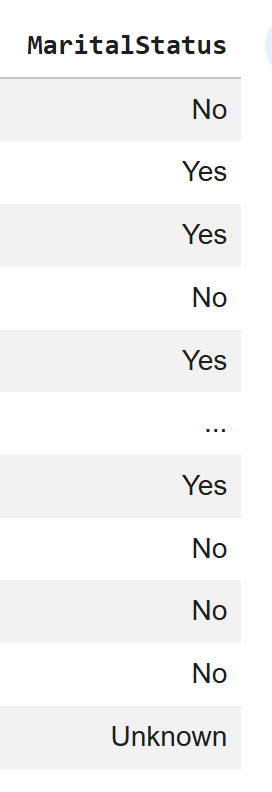

Скорее всего эти unknown надо просто удалять

Проверим дисбаланс классов


In [ ]:
df["Churn"].value_counts()


,count
Churn,
No,36336
Yes,14711


Ну по итогу дисбаланс нормальный, моделям нашим пох будет на это


In [ ]:
df.nunique()

,0
CustomerID,51047
Churn,2
MonthlyRevenue,12665
MonthlyMinutes,2719
TotalRecurringCharge,214
DirectorAssistedCalls,146
OverageMinutes,746
RoamingCalls,530
PercChangeMinutes,2262
PercChangeRevenues,2899


Уникальных значений категориальных мало, можем тогда за бейзлайн взять логрегрессию с one-hot или ориданар энкодингом, это будет быстро и просто, от этого скора будет отталкиваться тогда.

In [ ]:
df_drop = df.dropna()
y = df_drop["Churn"].map({"No": 0, "Yes": 1})
df_drop = df_drop.drop(columns=["Churn", "CustomerID"])

cat_df_drop = df_drop.select_dtypes(include='object').columns



https://scikit-learn.org/1.6/modules/generated/sklearn.preprocessing.OneHotEncoder.html

In [ ]:
cat_df_drop

Index(['ServiceArea', 'ChildrenInHH', 'HandsetRefurbished',
       'HandsetWebCapable', 'TruckOwner', 'RVOwner', 'Homeownership',
       'BuysViaMailOrder', 'RespondsToMailOffers', 'OptOutMailings',
       'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'NewCellphoneUser',
       'NotNewCellphoneUser', 'OwnsMotorcycle', 'HandsetPrice',
       'MadeCallToRetentionTeam', 'CreditRating', 'PrizmCode', 'Occupation',
       'MaritalStatus'],
      dtype='object')

In [ ]:
enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
cat_df_drop_encoder = enc.fit_transform(df_drop[cat_df_drop])


In [ ]:
cat_df_drop_encoder

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 1., 0., 0.]])

In [ ]:
cat_df_drop_encoder = pd.DataFrame(cat_df_drop_encoder, columns = enc.get_feature_names_out(cat_df_drop), index = df_drop.index)

get_feature_names_out - это функция OneHotEncoder
https://sklearn.org/stable/modules/feature_extraction.html

In [ ]:
X_num = df_drop.drop(columns=cat_df_drop)
final_df = pd.concat([X_num,cat_df_drop_encoder], axis=1)

In [ ]:
y

,Churn
0,1
1,1
2,0
3,0
4,1
...,...
51035,0
51037,0
51040,0
51041,1


In [ ]:
final_df

,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,...,Occupation_Crafts,Occupation_Homemaker,Occupation_Other,Occupation_Professional,Occupation_Retired,Occupation_Self,Occupation_Student,MaritalStatus_No,MaritalStatus_Unknown,MaritalStatus_Yes
0,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,0.7,0.7,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,0.3,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,52.0,7.7,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51035,0.00,76.0,30.0,0.00,0.0,0.0,0.0,0.0,5.7,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
51037,31.92,63.0,17.0,0.00,43.0,0.0,-38.0,-13.2,0.7,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
51040,71.99,724.0,70.0,0.00,4.0,0.9,-40.0,-2.0,14.3,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
51041,117.49,384.0,30.0,0.00,250.0,0.0,0.0,0.0,4.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(
    final_df,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = Pipeline([
    ("scaler", StandardScaler()), #Стандартизируем данные для логрегрессии
    ("clf", LogisticRegression(
        max_iter=5000,
        class_weight="balanced"
    ))
])

model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=5000))])

In [ ]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.6100009004824549
              precision    recall  f1-score   support

           0       0.78      0.59      0.67      7102
           1       0.36      0.57      0.44      2849

    accuracy                           0.59      9951
   macro avg       0.57      0.58      0.56      9951
weighted avg       0.66      0.59      0.61      9951



Дальше че то типо EDA

In [ ]:
df.describe()


,CustomerID,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,...,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,RetentionCalls,RetentionOffersAccepted,ReferralsMadeBySubscriber,IncomeGroup,AdjustmentsToCreditRating
count,5.104700e+04,50891.000000,50891.000000,50891.000000,50891.000000,50891.000000,50891.000000,50680.000000,50680.000000,51047.000000,...,51046.000000,51046.000000,51046.000000,50138.000000,50138.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000
mean,3.201957e+06,58.834492,525.653416,46.830088,0.895229,40.027785,1.236244,-11.547908,-1.191985,6.011489,...,1.805646,1.558751,380.545841,31.338127,21.144142,0.037201,0.018277,0.052070,4.324524,0.053911
std,1.169056e+05,44.507336,529.871063,23.848871,2.228546,96.588076,9.818294,257.514772,39.574915,9.043955,...,1.331173,0.905932,253.801982,22.094635,23.931368,0.206483,0.142458,0.307592,3.138236,0.383147
min,3.000002e+06,-6.170000,0.000000,-11.000000,0.000000,0.000000,0.000000,-3875.000000,-1107.700000,0.000000,...,1.000000,1.000000,-5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.100632e+06,33.610000,158.000000,30.000000,0.000000,0.000000,0.000000,-83.000000,-7.100000,0.700000,...,1.000000,1.000000,205.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.201534e+06,48.460000,366.000000,45.000000,0.250000,3.000000,0.000000,-5.000000,-0.300000,3.000000,...,1.000000,1.000000,329.000000,36.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000
75%,3.305376e+06,71.065000,723.000000,60.000000,0.990000,41.000000,0.300000,66.000000,1.600000,7.700000,...,2.000000,2.000000,515.000000,48.000000,42.000000,0.000000,0.000000,0.000000,7.000000,0.000000
max,3.399994e+06,1223.380000,7359.000000,400.000000,159.390000,4321.000000,1112.400000,5192.000000,2483.500000,221.700000,...,24.000000,15.000000,1812.000000,99.000000,99.000000,4.000000,3.000000,35.000000,9.000000,25.000000


In [ ]:
df.describe()



,CustomerID,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,...,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,RetentionCalls,RetentionOffersAccepted,ReferralsMadeBySubscriber,IncomeGroup,AdjustmentsToCreditRating
count,5.104700e+04,50891.000000,50891.000000,50891.000000,50891.000000,50891.000000,50891.000000,50680.000000,50680.000000,51047.000000,...,51046.000000,51046.000000,51046.000000,50138.000000,50138.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000
mean,3.201957e+06,58.834492,525.653416,46.830088,0.895229,40.027785,1.236244,-11.547908,-1.191985,6.011489,...,1.805646,1.558751,380.545841,31.338127,21.144142,0.037201,0.018277,0.052070,4.324524,0.053911
std,1.169056e+05,44.507336,529.871063,23.848871,2.228546,96.588076,9.818294,257.514772,39.574915,9.043955,...,1.331173,0.905932,253.801982,22.094635,23.931368,0.206483,0.142458,0.307592,3.138236,0.383147
min,3.000002e+06,-6.170000,0.000000,-11.000000,0.000000,0.000000,0.000000,-3875.000000,-1107.700000,0.000000,...,1.000000,1.000000,-5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.100632e+06,33.610000,158.000000,30.000000,0.000000,0.000000,0.000000,-83.000000,-7.100000,0.700000,...,1.000000,1.000000,205.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.201534e+06,48.460000,366.000000,45.000000,0.250000,3.000000,0.000000,-5.000000,-0.300000,3.000000,...,1.000000,1.000000,329.000000,36.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000
75%,3.305376e+06,71.065000,723.000000,60.000000,0.990000,41.000000,0.300000,66.000000,1.600000,7.700000,...,2.000000,2.000000,515.000000,48.000000,42.000000,0.000000,0.000000,0.000000,7.000000,0.000000
max,3.399994e+06,1223.380000,7359.000000,400.000000,159.390000,4321.000000,1112.400000,5192.000000,2483.500000,221.700000,...,24.000000,15.000000,1812.000000,99.000000,99.000000,4.000000,3.000000,35.000000,9.000000,25.000000


In [ ]:
df

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51042,3399958,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,6,No,0,60,No,1-Highest,Suburban,Other,Yes
51043,3399974,No,95.17,1745.0,85.0,0.99,45.0,4.7,122.0,15.9,...,0,9,No,1,60,No,3-Good,Other,Other,No
51044,3399978,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,7,No,1,80,No,5-Low,Other,Clerical,No
51045,3399990,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,9,No,0,30,No,5-Low,Other,Other,No


In [ ]:


import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

In [ ]:
X = df.drop(columns=['Churn', 'CustomerID'])
y = df['Churn'].map({'Yes': 1, 'No': 0})

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = numeric_cols.drop(['IncomeGroup', 'AdjustmentsToCreditRating'], errors='ignore')
# Добавляем числовые колонки, которые pandas мог определить как object, если нужно,
# или просто берем те, что есть.

categorical_cols = X.select_dtypes(include=['object']).columns

In [ ]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy='median')), # пустые места заполняем медианой
    ("scaler", StandardScaler()) # стандартим числа
])

In [ ]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy='most_frequent')), # тут берем самое частое значение для пропусков
    ('onehot', OneHotEncoder(handle_unknown="ignore")) # кодируем в 0 и 1
])

In [ ]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols), # числа сюда
    ("cat", categorical_pipeline, categorical_cols) # категории сюда
])
# собираем все трансформеры в одну кучу

In [ ]:
X = df.drop(columns=["Churn", "CustomerID"])
y = df["Churn"].map({"Yes": 1, "No": 0})

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [ ]:
X_train

,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
39873,39.79,234.0,55.0,0.25,0.0,1.7,31.0,8.8,6.7,0.7,...,0,0,No,0,Unknown,No,2-High,Suburban,Other,Unknown
28355,60.19,551.0,60.0,0.74,0.0,0.3,-88.0,-10.2,2.7,32.7,...,0,7,No,0,150,No,2-High,Suburban,Crafts,Yes
29134,85.41,642.0,28.0,0.25,134.0,0.0,129.0,22.8,29.7,0.0,...,0,4,No,0,Unknown,No,2-High,Suburban,Crafts,No
23500,30.18,281.0,30.0,0.00,0.0,0.0,132.0,-0.2,4.0,0.0,...,0,3,No,0,150,No,3-Good,Suburban,Other,Unknown
44191,179.29,1459.0,95.0,0.50,118.0,48.6,-1360.0,-77.0,21.7,11.0,...,0,4,No,0,Unknown,No,3-Good,Rural,Other,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36974,19.36,18.0,17.0,0.00,0.0,4.5,-18.0,-9.4,0.0,0.0,...,0,4,No,0,Unknown,No,1-Highest,Town,Professional,Yes
50483,50.30,140.0,50.0,0.00,0.0,0.0,-77.0,-0.3,1.3,3.0,...,0,6,No,0,Unknown,No,1-Highest,Suburban,Professional,Yes
44961,15.73,713.0,10.0,1.73,0.0,0.0,-143.0,0.2,4.0,55.0,...,0,0,No,0,Unknown,No,3-Good,Suburban,Other,Unknown
47246,80.69,504.0,50.0,0.00,77.0,0.0,48.0,-30.7,1.7,0.7,...,0,6,No,0,Unknown,No,4-Medium,Suburban,Other,No


In [ ]:
X_train = preprocessor.fit_transform(X_train)


In [ ]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2205198 stored elements and shape (40837, 831)>

In [ ]:
X_test = preprocessor.transform(X_test)


In [ ]:
model.eval()
with torch.no_grad():
    # считаем логиты и в вероятности их сразу
    pred_logits = model(X_test_tensor.to(device))
    probs = torch.sigmoid(pred_logits).cpu().numpy().flatten()

# порог стандартный 0.5
classes = (probs > 0.5).astype(int)

# чекнем что по метрикам вышло
print(f"ROC-AUC: {roc_auc_score(y_test, probs)}")
print(classification_report(y_test, classes))

In [ ]:
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

In [ ]:
y_train = y_train.to_numpy().reshape(-1, 1)
y_test = y_test.to_numpy().reshape(-1, 1)
#reshape(-1,1) - делается чтобы y имел форму колонка, а не одномерный массив
#было (40000,) стало (40000, 1)

In [ ]:
X_train_tensor = torch.tensor(X_train.toarray(), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

In [ ]:
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size = 256, shuffle=True)

In [ ]:
#дальше сама модель
class ChurnPerceptron(nn.Module): #создаем новый класс модели nn.Module - это базовый каласс Pytorch для всех нейронок
#если модель наследуется от nn.Module пайторч понимает, какие и модели слои, какие параметры надо обучать, как переносить модель на GPU
#то есть это означает что мы создаем модель PyTorch, основанную на nn.Module
  def __init__(self, input_dim):
    super().__init__()

    self.net = nn.Sequential(
        nn.Linear(input_dim, 128),
        nn.ReLU(),
        nn.Dropout(0.2),

        nn.Linear(128,64),
        nn.ReLU(),
        nn.Dropout(0.2),

        nn.Linear(64,1)
    )
  def forward(self, x):
    return self.net(x)

In [ ]:
!pip install wand

In [ ]:
import wandb

In [ ]:
wandb.login('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')

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [ ]:
#обучение модели
device = "cuda" if torch.cuda.is_available() else "cpu"

model = ChurnPerceptron(input_dim=X_train.shape[1]).to(device)
#Эта строка создаёт модель и переносит её на нужное устройство

criterion = nn.BCEWithLogitsLoss() # это функция ошибки для бинарной классификации в PyTorch
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)



In [ ]:
from sklearn.metrics import roc_auc_score

model.eval()

with torch.no_grad():
    logits = model(X_test_tensor.to(device))
    probs = torch.sigmoid(logits).cpu().numpy().ravel()

auc = roc_auc_score(y_test, probs)
print("ROC-AUC:", auc)

ROC-AUC: 0.49942529988136064


In [ ]:
#TabNet специальная модель для табличных данных
# Главная идея TabNet - модель сама учится выбирать важныые признаки на разных шагах
# То есть она не просто пропускает все признаки через полносвязные слои, как перцептрон,
# а использует attention-механизм для отбора признаков.



In [ ]:
!pip install Pytorch-tabnet

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

from pytorch_tabnet.tab_model import TabNetClassifier



In [ ]:
import wandb
from sklearn.metrics import roc_auc_score

# запускаем логирование в вандиби
run = wandb.init(
    project='GP_5',
    name='churn_dl_training',
    config={
        'learning_rate': 0.001,
        'epochs': 30,
        'batch_size': 256,
        'architecture': 'ChurnPerceptron'
    }
)

epochs = run.config.epochs
model.train()
for epoch in range(epochs):
    total_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        logits = model(batch_X)
        loss = criterion(logits, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # валидация на каждой эпохе
    model.eval()
    with torch.no_grad():
        val_logits = model(X_test_tensor.to(device))
        val_probs = torch.sigmoid(val_logits).cpu().numpy().ravel()
        auc = roc_auc_score(y_test, val_probs)
    model.train()

    # шлем логи
    wandb.log({"epoch": epoch + 1, "loss": avg_loss, "val_roc_auc": auc})
    print(f"Эпоха {epoch + 1}, loss: {avg_loss:.4f}, auc: {auc:.4f}")

run.finish()

Epoch 1/30, loss: 0.5943, val_auc: 0.6159
Epoch 2/30, loss: 0.5804, val_auc: 0.6256
Epoch 3/30, loss: 0.5758, val_auc: 0.6274
Epoch 4/30, loss: 0.5703, val_auc: 0.6322
Epoch 5/30, loss: 0.5648, val_auc: 0.6300
Epoch 6/30, loss: 0.5591, val_auc: 0.6327
Epoch 7/30, loss: 0.5518, val_auc: 0.6314
Epoch 8/30, loss: 0.5444, val_auc: 0.6220
Epoch 9/30, loss: 0.5358, val_auc: 0.6321
Epoch 10/30, loss: 0.5269, val_auc: 0.6220
Epoch 11/30, loss: 0.5186, val_auc: 0.6190
Epoch 12/30, loss: 0.5078, val_auc: 0.6207
Epoch 13/30, loss: 0.4985, val_auc: 0.6191
Epoch 14/30, loss: 0.4874, val_auc: 0.6105
Epoch 15/30, loss: 0.4793, val_auc: 0.6060
Epoch 16/30, loss: 0.4677, val_auc: 0.6111
Epoch 17/30, loss: 0.4629, val_auc: 0.6002
Epoch 18/30, loss: 0.4499, val_auc: 0.6066
Epoch 19/30, loss: 0.4393, val_auc: 0.6047
Epoch 20/30, loss: 0.4308, val_auc: 0.6003
Epoch 21/30, loss: 0.4240, val_auc: 0.5994
Epoch 22/30, loss: 0.4151, val_auc: 0.5981
Epoch 23/30, loss: 0.4068, val_auc: 0.5975
Epoch 24/30, loss: 0

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
loss,██▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁
val_roc_auc,▅▇▇████▆█▆▆▆▆▅▄▅▃▄▄▃▃▃▃▂▃▃▃▁▁▁
epoch,30
loss,0.36234
val_roc_auc,0.58861


# Модель Перцептрона (Deep Learning)
Этот раздел содержит полный цикл разработки MLP: предобработка, определение архитектуры и обучение.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import wandb
from sklearn.metrics import roc_auc_score
import numpy as np

# 1. Подготовка тензоров (с конвертацией sparse -> dense)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_tensor = torch.tensor(X_train.toarray(), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.toarray(), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=256, shuffle=True)

In [ ]:
class ChurnPerceptron(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

model = ChurnPerceptron(input_dim=X_train.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
run = wandb.init(
    project='GP_5',
    name='perceptron_dedicated_run',
    config={
        'learning_rate': 0.001,
        'epochs': 30,
        'batch_size': 256,
        'architecture': 'ChurnPerceptron'
    }
)

# основной цикл обучения
epochs = run.config.epochs
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # чекаем аук на тесте
    model.eval()
    with torch.no_grad():
        val_logits = model(X_test_tensor.to(device))
        val_probs = torch.sigmoid(val_logits).cpu().numpy().ravel()
        auc = roc_auc_score(y_test, val_probs)

    avg_loss = total_loss / len(train_loader)
    wandb.log({"epoch": epoch + 1, "loss": avg_loss, "val_roc_auc": auc})
    if (epoch + 1) % 5 == 0:
        print(f"Эпоха [{epoch+1}/{epochs}], лосс: {avg_loss:.4f}, аук: {auc:.4f}")

run.finish()